# SpatioEv: General Density Analysis

This notebook computes spatial density metrics for cells in tissue sections.

**Biological purpose**: Understanding how densely cells are distributed across tissue regions
reveals spatial organisation. Computing phenotype-specific density maps highlights regions
enriched for particular cell types (e.g., tumour cores, immune hotspots). Kernel density
estimation (KDE) provides continuous density landscapes for individual phenotypes.

**Workflow**:
1. Assign spatial tiles
2. Compute general cell density per tile
3. Compute phenotype-specific density
4. Correlate phenotype densities
5. Estimate KDE density for a specific phenotype

In [1]:
# import dependencies
import matplotlib
%matplotlib inline
import os
import sys
import spatioev as sv
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

# Import Scimap
try:
    import scimap as sm
except ImportError:
    print('scimap not installed; scimap-dependent cells will be skipped.')
    sm = None

from spatioev.config import ClusteringConfig

Running SCIMAP  2.3.5


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/mpl_scatter_density/__init__.py:4: UserWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [2]:
# set a working directory
wdir = ('/Users/shihongwu/SpatioEv')
os.chdir(wdir)

In [3]:
# ── Data loading ───────────────────────────────────────────────────────────
import os
from pathlib import Path

DATA_PATH = "data/exp_1/exp_1.h5ad"

try:
    adata = sv.load_h5ad(DATA_PATH)
    print(f"Loaded {adata.n_obs} cells from {DATA_PATH}")
except FileNotFoundError:
    print(f"WARNING: {DATA_PATH} not found — generating synthetic data for demonstration.")
    import anndata as ad
    import numpy as np, pandas as pd

    rng = np.random.default_rng(42)
    n_cells = 500
    markers = ["DNA_1", "PCK", "CD45", "SMA", "FN", "COL6A1", "COL4A1",
               "CK19", "CD3", "CD4", "CD68", "CD11c", "CD14",
               "Vimentin", "PDPN", "CD90", "Ki67"]
    markers = list(dict.fromkeys(markers))  # dedupe

    X = rng.exponential(1, size=(n_cells, len(markers))).astype("float32")

    phenos = ["tumour", "CD4 T cells", "CD8 T cells", "Fibroblasts", "Macrophages", "B cells", "Endothelial"]
    obs = pd.DataFrame({
        "X_centroid": rng.uniform(0, 2000, n_cells),
        "Y_centroid": rng.uniform(0, 2000, n_cells),
        "area": rng.gamma(4, 50, n_cells),
        "nc_ratio": rng.beta(2, 5, n_cells),
        "eccentricity": rng.uniform(0, 1, n_cells),
        "major_axis_length": rng.gamma(3, 10, n_cells),
        "minor_axis_length": rng.gamma(2, 6, n_cells),
        "perimeter": rng.gamma(4, 15, n_cells),
        "convex_area": rng.gamma(4, 55, n_cells),
        "equivalent_diameter": rng.gamma(3, 8, n_cells),
        "solidity": rng.beta(8, 2, n_cells),
        "feret_diameter_max": rng.gamma(4, 12, n_cells),
        "major_minor_axis_ratio": rng.gamma(2, 1, n_cells) + 1,
        "perim_square_over_area": rng.gamma(3, 5, n_cells),
        "major_axis_equiv_diam_ratio": rng.gamma(2, 1, n_cells),
        "convex_hull_resid": rng.beta(1, 5, n_cells),
        "circularity": rng.beta(4, 2, n_cells),
        "fractal_dimension": rng.uniform(1, 2, n_cells),
        "boundary_irregularity": rng.gamma(2, 0.1, n_cells),
        "centroid_dif": rng.gamma(1, 2, n_cells),
        "num_concavities": rng.poisson(3, n_cells).astype(float),
        "imageid": "exp",
        "annotated_clusters_update3": rng.choice(phenos, n_cells),
        "svm_prediction": rng.choice(phenos, n_cells),
    })

    adata = ad.AnnData(X=X, obs=obs,
                       var=pd.DataFrame(index=markers))
    adata.obs.index = [f"cell_{i}" for i in range(n_cells)]


Loaded 51932 cells from data/exp_1/exp_1.h5ad


In [4]:
# Load SVM phenotyping results
ANN_PATH = "results/svm_phenotyping_results.csv"

try:
    ann = pd.read_csv(ANN_PATH, index_col=0)
    ann = ann[["annotated_clusters_update3", "svm_prediction"]]
    adata.obs = adata.obs.join(ann, how="left")
    print(f"Loaded annotations from {ANN_PATH}")
except FileNotFoundError:
    print(f"WARNING: {ANN_PATH} not found — using synthetic annotation columns.")
    # annotated_clusters_update3 and svm_prediction already present in synthetic data


Loaded annotations from results/svm_phenotyping_results.csv


/Users/shihongwu/SpatioEv/spatioev/tl/density.py:105: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



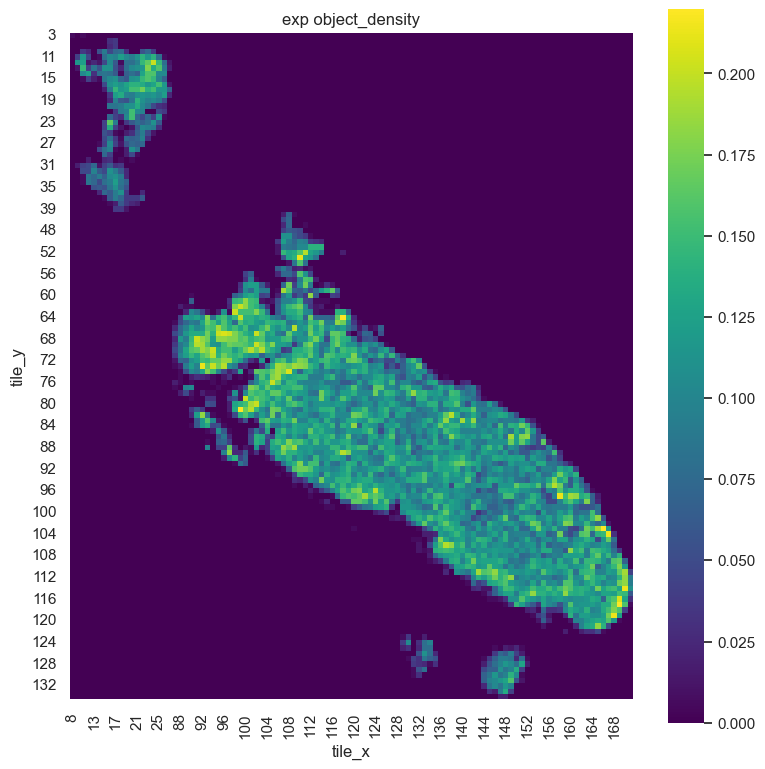

In [5]:
df = sv.assign_tiles(adata)

density = sv.compute_general_density(df)

sv.plot_density_heatmap(
    density,
    imageid="exp"
)
plt.show()
plt.close('all')

In [6]:
pheno_density = sv.compute_phenotype_density(df, phenotype_key="annotated_clusters_update3")

/Users/shihongwu/SpatioEv/spatioev/tl/density.py:157: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



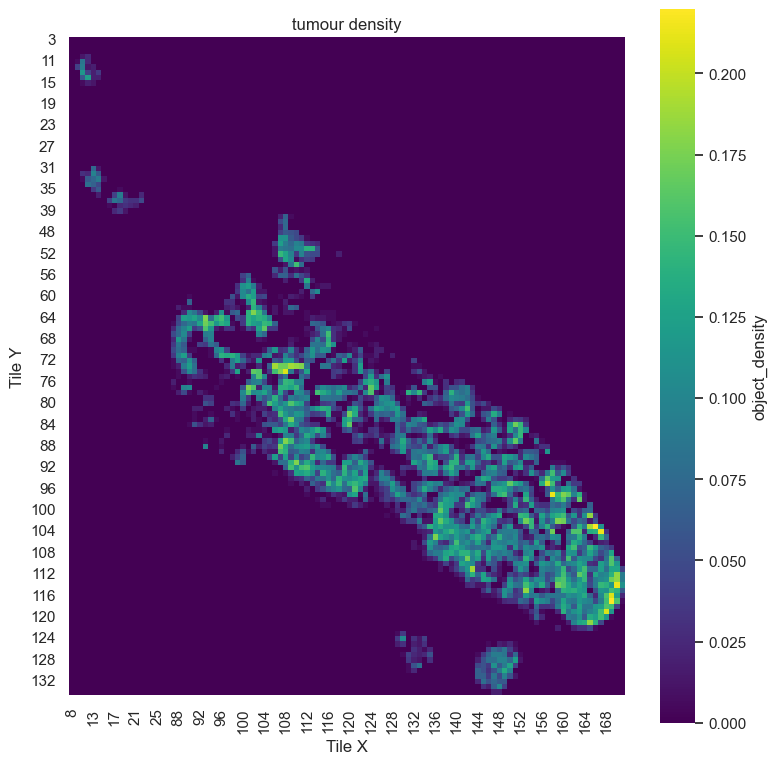

In [7]:
sv.plot_phenotype_density_heatmap(
    pheno_density,
    phenotype="tumour",
    phenotype_key="annotated_clusters_update3"
)
plt.show()
plt.close('all')

In [8]:
corr = sv.phenotype_density_correlation(pheno_density,
                                        phenotype_key="annotated_clusters_update3",)

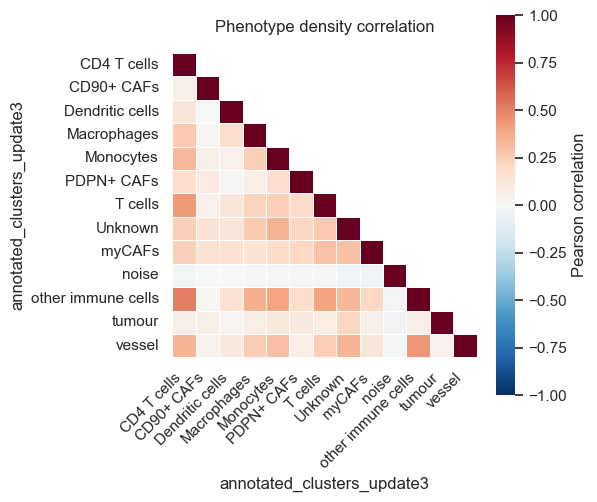

In [9]:
sv.plot_density_correlation(corr, annot=False, cmap="RdBu_r")
plt.show()
plt.close('all')

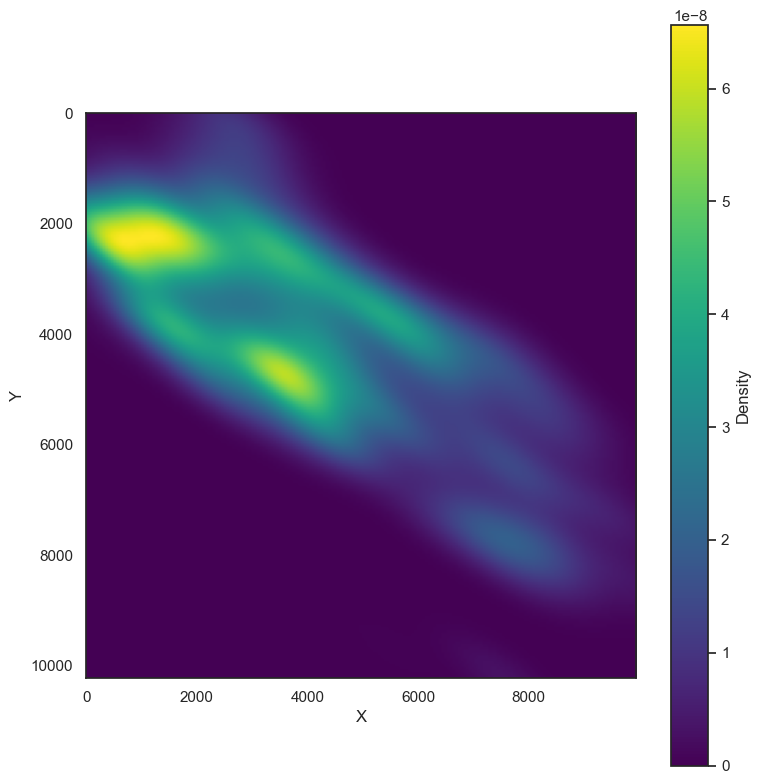

In [10]:
X, Y, Z = sv.compute_kde_density(
    adata,
    phenotype_key="annotated_clusters_update3",
    phenotype="CD4 T cells",
)

sv.plot_kde_density(X, Y, Z)
plt.show()
plt.close('all')